# Gait Recovery Pipeline — Integrated Run

This notebook runs the full 5-stage pipeline in order:

1. **Extraction** — TSFresh feature extraction (+ optional relevance filtering)
2. **Transform & Select** — skew correction, scaling, (optional) ANOVA slope selection
3. **Recovery Scores** — kNN, Mahalanobis, CKS, Ridge (each run only if the data supports it)
4. **Visualize & Analyze Scores** — recovery curves, bar plots, statistics
5. **Visualize & Analyze Feature Importance** — consensus feature importance across metrics

Each stage writes its own intermediate CSV/parquet files to `outputs/`.
This runs them all in sequence and passes data between them directly, and shows each stage's output.

All lab-specific settings (paths, column names, thresholds, reproducibility
options) live in `config.yaml`, not in this notebook. Edit that file rather than the cells below.

All of the pipeline's logic lives in `pipeline_functions.py` (schema
mapping, scenario detection, and all 5 stages) plus `pinned_env.py` (optional
pinned-environment support, see `reproducibility.use_pinned_versions` in
config.yaml). Both only define functions (nothing runs on its own there).
Do not edit either unless changing the pipeline's logic itself.

## Setup — mount Drive, set paths, load config

### Choosing a runtime on Colab

Extraction and transform/select are CPU-bound (tsfresh feature extraction, PCA/Ridge), so pick runtime based on **RAM** and **CPU cores** (GPU runtime won't necessarily speed up unless has more cores):

- **More cores**: tsfresh and the I/O-parallel file loading both scale roughly linearly with core count, so a high-RAM/high-CPU runtime (Colab Pro's "High-RAM" or a Background Execution / TPU-adjacent CPU tier) will significantly cut extraction time on 1000+ files.
- **More RAM**: avoids slowdowns/crashes when many files' features are held in memory at once during extraction and the transform/select step.

Pick a High-RAM runtime (need Colab Pro/Pro+) with more cores (run below cell to see). On free-tier Colab there is a cap at whatever cores/RAM Google assigns that session (usually 2 cores), so extraction would take a while. Consider downloading files and running on local machine instead.

To check what you're actually connected to:

In [1]:
import os
print(f"CPU cores: {os.cpu_count()}")
try:
    import psutil
    print(f"RAM: {psutil.virtual_memory().total / 1e9:.1f} GB")
except ImportError:
    print("RAM: (psutil not installed)")


In [2]:
# Setup -- runs on Google Colab or locally.
#
# On Colab: set PROJECT_DIR to the project folder in your Drive, then run.
# Locally: nothing to set; start Jupyter from inside the project folder.
import os
import sys
from pathlib import Path

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final"  # Colab only

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_ROOT = Path(PROJECT_DIR)
    if not (PROJECT_ROOT / "scripts" / "pipeline_functions.py").exists():
        raise FileNotFoundError(
            f"No scripts/pipeline_functions.py under {PROJECT_ROOT}. "
            "Set PROJECT_DIR above to the project folder in your Drive."
        )
else:
    # Walk up from the working directory to find the project root.
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "scripts" / "pipeline_functions.py").exists():
        if PROJECT_ROOT == PROJECT_ROOT.parent:
            raise RuntimeError(
                "Could not find the project root: no scripts/pipeline_functions.py "
                f"in any parent of {Path.cwd()}. Start Jupyter inside the project folder."
            )
        PROJECT_ROOT = PROJECT_ROOT.parent

# Convention: pipeline_functions.py and pinned_env.py live in PROJECT_ROOT/scripts,
# config.yaml at PROJECT_ROOT. Data (data/, outputs/, animal_data_key.xlsx)
# lives under PROJECT_ROOT, as set in config.yaml's own `paths` section.
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
CONFIG_PATH = PROJECT_ROOT / "config.yaml"
sys.path.insert(0, str(SCRIPTS_DIR))

print(f"Running on:    {'Colab' if IN_COLAB else 'local'}")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Scripts dir:   {SCRIPTS_DIR}")
print(f"Config path:   {CONFIG_PATH}")


In [3]:
# Package check. Works on Colab and locally.
#
# numpy < 2.2 and pandas < 3.0 are what reproduce the reference results, so the
# versions in requirements.txt are not optional. On Colab this installs them and
# restarts the runtime once (you'll see a "session crashed" notice -- expected;
# just run the notebook again from the top). Locally it only reports what's
# wrong, so it never changes an environment you manage yourself.
import subprocess, sys, os
from importlib.metadata import version, PackageNotFoundError

def _installed(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return None

wrong = []
try:
    from packaging.requirements import Requirement
    for line in open("requirements.txt"):
        line = line.split("#")[0].strip()
        if "==" not in line:
            continue
        req = Requirement(line)
        if req.marker is not None and not req.marker.evaluate():
            continue          # pin is for a different Python version
        want = str(req.specifier).lstrip("=")
        if _installed(req.name) != want:
            wrong.append(f"{req.name}=={want} (have {_installed(req.name)})")
except ImportError:
    wrong = ["(could not check versions)"]

if not wrong:
    import numpy, pandas
    print(f"environment OK - numpy {numpy.__version__}, pandas {pandas.__version__}")
elif IN_COLAB:
    print("Installing pinned versions:")
    for w in wrong:
        print("   ", w)
    print("\nThis takes a few minutes. Output follows -- don't interrupt it.\n", flush=True)
    proc = subprocess.Popen(
        [sys.executable, "-m", "pip", "install", "--disable-pip-version-check",
         "-r", "requirements.txt"],
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in proc.stdout:
        print(line, end="", flush=True)
    if proc.wait() != 0:
        raise RuntimeError("pip install failed -- see the output above.")
    print("\nInstalled. Restarting the runtime so the versions take effect --")
    print("run the notebook again from the top.", flush=True)
    os.kill(os.getpid(), 9)
else:
    print("These packages don't match requirements.txt:")
    for w in wrong:
        print("   ", w)
    raise SystemExit(
        "Install them before running:  pip install -r requirements.txt\n"
        "(numpy < 2.2 and pandas < 3.0 are required to reproduce the reference results.)")


In [4]:
# Load config.yaml first so the reproducibility.force_single_threaded_blas
# setting below can be honored BEFORE numpy/pipeline_functions get imported.
import yaml

with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f)

if "paths" not in config:
    raise ValueError(
        "config.yaml doesn't have the expected 'paths' key. Check that the file is actually plain YAML and not, e.g., a Colab notebook saved with a .yaml extension."
    )

print("Config loaded.")

Config loaded.


In [5]:
# Optionally force single-threaded BLAS (reduces thread-count-dependent
# floating-point noise in PCA/Ridge), can set preference in config.yaml.
# Must run before numpy is imported anywhere (before `import pipeline_functions`).
import os

if config.get("reproducibility", {}).get("force_single_threaded_blas", True):
    os.environ['OMP_NUM_THREADS'] = "1"
    os.environ['MKL_NUM_THREADS'] = "1"
    os.environ['OPENBLAS_NUM_THREADS'] = "1"
    print("Single-threaded BLAS enforced (reproducibility.force_single_threaded_blas = true).")
else:
    print("Single-threaded BLAS NOT enforced (reproducibility.force_single_threaded_blas = false).")

Single-threaded BLAS enforced (reproducibility.force_single_threaded_blas = true).


## Load pipeline_functions

In [6]:
import pipeline_functions as pf

print("pipeline_functions imported successfully.")

pipeline_functions imported successfully.


## Step 0 — Load animal key, apply schema mapping, profile the dataset

In [7]:
import pandas as pd

config["paths"]["project_root"] = str(PROJECT_ROOT)
paths_cfg = config["paths"]
key_file = PROJECT_ROOT / paths_cfg["animal_key_file"]

print(f"Loading animal key from: {key_file}")
key_df = pd.read_excel(key_file)
print(f"  Loaded {len(key_df)} rows\n")

std_df, profile = pf.build_dataset_profile(key_df, config)
pf.print_profile_summary(profile)

rp = pf._resolve_project_paths(config)

Loading animal key from: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/animal_data_key.xlsx
  Loaded 1312 rows

DATASET PROFILE
  Animal key rows: 1312
  Treatment groups (3): ['HiDose', 'LoDose', 'Vehicle']
  Timepoints (days): [0, 7, 14, 21, 28, 35, 42]
  Baseline (day 0) present: True
  Post-baseline data present: True

  Animals per group:
    HiDose: 12
    LoDose: 13
    Vehicle: 13

  Scenario detected: longitudinal_multi_group
  Resolved injury reference timepoint: 7
  Resolved reference group: Vehicle

  Warnings:
    - schema_mapping.date_code_col not set; using default value '' for all rows.



## Pinned environment setup (see `reproducibility.use_pinned_versions` in config.yaml)
### Default: don't use pinned — older package versions can be slower and don't necessarily give closer cross-environment agreement

In [8]:
from pinned_env import ensure_pinned_env
import subprocess, sys

repro_cfg = config.get("reproducibility", {})
use_pinned = repro_cfg.get("use_pinned_versions", False)
PINNED_PY = None

if use_pinned:
    req_file = PROJECT_ROOT / repro_cfg.get("pinned_requirements_file", "requirements.txt")
    print(f"Setting up pinned environment from: {req_file}")
    PINNED_PY = ensure_pinned_env(req_file)
    print(f"Pinned interpreter ready: {PINNED_PY}")
else:
    print("reproducibility.use_pinned_versions = false; running in this notebook's own kernel.")

def run_pinned_step(step: str):
    cmd = [PINNED_PY, "-u", str(SCRIPTS_DIR / "pinned_env.py"), step, str(PROJECT_ROOT)]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    for i, line in enumerate(proc.stdout):
        if "|" not in line or i % 100 == 0:
            sys.stdout.write(line)
            sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise RuntimeError(f"Pinned step '{step}' failed (exit code {proc.returncode})")

reproducibility.use_pinned_versions = false; running in this notebook's own kernel.


## Step 1 — Extraction

In [9]:
if use_pinned:
    run_pinned_step("extraction")
    extracted_df = pd.read_csv(rp["output_dir"] / "extracted_features.csv")
else:
    extracted_df = pf.run_extraction(config, std_df, profile)

1. LOAD ALL FILES

Found 1312 Excel files in /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/data

2. FEATURE EXTRACTION WITH TSFRESH

No saved features found, extracting now.
Found 46 time series features


Processing files:  98%|█████████▊| 1281/1312 [03:03<00:04,  7.63it/s]/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
Processing files: 100%|██████████| 1312/1312 [03:07<00:00,  7.01it/s]


Processed 1312 files successfully



Extracting TSFresh features (this will take a while)...


Feature Extraction: 100%|██████████| 60/60 [21:53<00:00, 21.89s/it]


  Extracted 36018 features from 1312 files

  Imputing NaN values...
  Saving to: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/extraction_cache/tsfresh_extracted_features.parquet
  Saved 1312 files x 36026 features

3. CALCULATE TWO-STAGE RELEVANCE TABLES

  Stage 1: Injury relevance (baseline vs 7dpi); will run
  Stage 2: Treatment relevance (reference group vs others); will run

  Stage 1: Injury relevance...
    Files: 377 (189 baseline, 188 injured)
    Found 10003 significant features

  Stage 2: Treatment relevance...
    NOTE: no timepoints exist strictly after the injury reference; comparing treatment groups across all injured data instead of restricting to a later window.
    Files: 188 at post-injury timepoints
    Groups: {1: 124, 0: 64} (0=Vehicle, 1=Other)
    Found 0 significant features

4. SELECT FEATURES BY RELEVANCE (IF COMPUTED)

  Combining relevance tables using TSFresh...
  Combined relevance: 10003 significant features
    Se

## Step 2 — Transform & Select

In [10]:
if use_pinned:
    run_pinned_step("transform")
    transformed_df = pd.read_csv(rp["output_dir"] / "transformed_selected_features.csv")
else:
    fixed_lambdas = pf.load_fixed_lambdas(config)
    transformed_df = pf.run_transform_select(config, profile, df=extracted_df, fixed_lambdas=fixed_lambdas)

1. LOAD EXTRACTED FEATURES

  Loaded 1312 samples
  Features: 233
  Treatment groups: ['Vehicle' 'HiDose' 'LoDose']
  Timepoints: [np.int64(0), np.int64(7), np.int64(14), np.int64(21), np.int64(28), np.int64(35), np.int64(42)]

Missing value check:
  Total rows with missing values: 0

2. APPLY TRANSFORMATIONS (SKEW ADJUSTMENT AND SCALING)
  Applied skew adjustment to 120/233 features
  Standardized all features globally

Transformations complete

3. FEATURE SELECTION (ANOVA SLOPE METHOD)

ANOVA Slope Method (p < 0.1)
  Step 1: Aggregating across runs...
  Step 2: Computing recovery slopes per animal...
  Computed slopes for 233 features
  Mean F-statistic: 1.526
  Mean p-value: 0.3780

  Selected 44 features with p < 0.1
  Selection rate: 18.9%

  Top 5 features by F-statistic:
    iliac_crest_height_left__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.6: F=6.17, p=0.0051
    iliac_crest_height_left__change_quantiles__f_agg_"var"__isabs_True__qh_1.0__ql_0.4: F=6.06, p=0.0055
 

## Step 3 — Recovery Scores

In [11]:
if use_pinned:
    run_pinned_step("recovery")
    scores_df = pd.read_csv(rp["output_dir"] / "recovery_scores" / "recovery_scores.csv")
else:
    scores_df = pf.run_recovery_scores(config, profile, df=transformed_df)

1. LOAD TRANSFORMED, SELECTED FEATURES

  Loaded 1312 samples
  Features: 44
  Treatment groups: ['Vehicle' 'HiDose' 'LoDose']
  Timepoints: [np.int64(0), np.int64(7), np.int64(14), np.int64(21), np.int64(28), np.int64(35), np.int64(42)]

METRIC AVAILABILITY CHECK
  Baseline animals: 38
  Injured-reference animals (tp=7, group=Vehicle): 13

  kNN: WILL RUN
  Mahalanobis: WILL RUN
  CKS: WILL RUN
  Ridge: WILL RUN

Running PCA (needed for CKS and/or Mahalanobis)
  Computed 44 principal components
  PC1 explains 43.2% of variance
  PC1-PC10 explain 93.3% of variance

Saved PCA loadings to: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/recovery_scores/feature_importance/pc_importance.csv

Metric: CKS Score
Saved feature importance to: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/recovery_scores/feature_importance/cks_importance.csv

Metric: Mahalanobis Distance
Saved feature importance to: /content/drive/MyDrive/Co

## Step 4 — Visualize & Analyze Scores

RECOVERY SCORE VISUALIZATION AND ANALYSIS

  Metrics available: ['CKS', 'Mahalanobis', 'kNN_Baseline', 'Ridge']

Generating Recovery Curves
Saved: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/recovery_score_analysis/recovery_curves_4.png

Exporting Statistics
Saved: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/recovery_score_analysis/recovery_statistics.xlsx

Statistical Results:
      Metric HiDose_recovery_trend LoDose_recovery_trend Vehicle_recovery_trend Vehicle_vs_HiDose_p_permutation Vehicle_vs_HiDose_p_anova  Vehicle_vs_HiDose_cohens_d Vehicle_vs_LoDose_p_permutation Vehicle_vs_LoDose_p_anova  Vehicle_vs_LoDose_cohens_d
         CKS              0.4382**              0.4798**               0.3462**                        0.0077**                   0.0177*                    1.067707                         0.0180*                   0.0364*                    0.886499
 Mahalanobis              0.4600**   

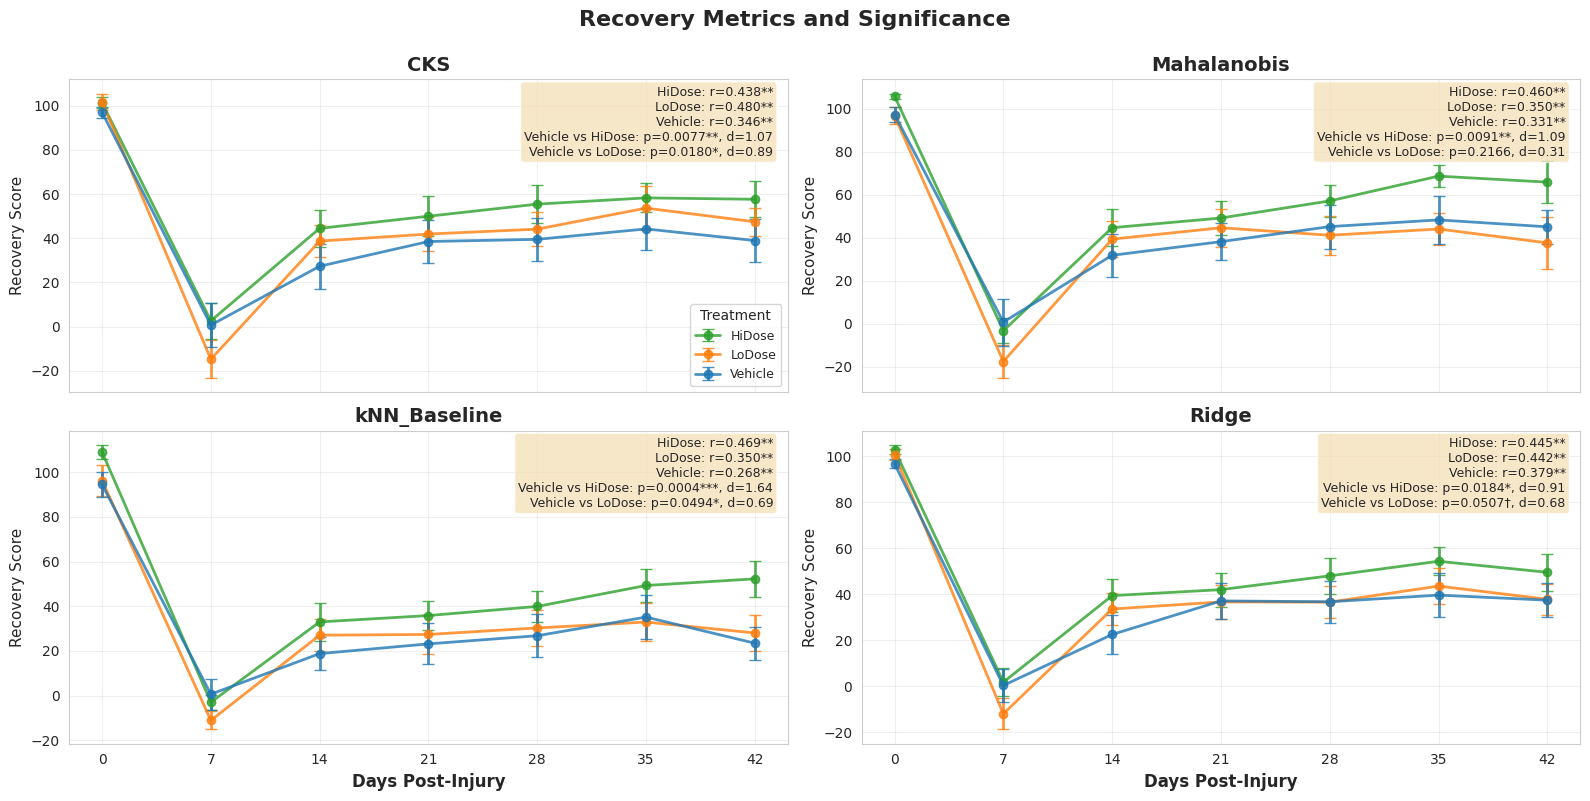

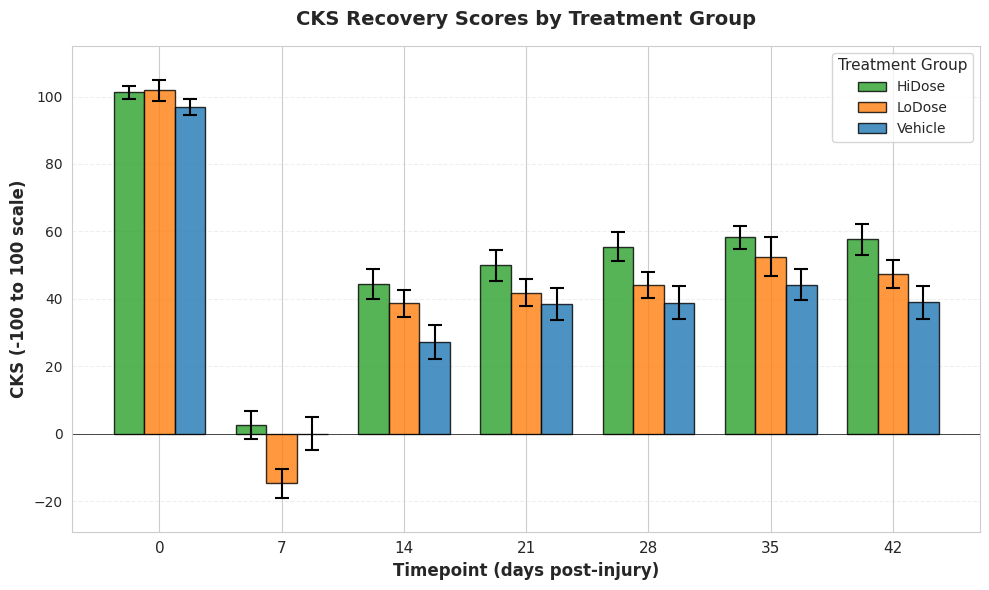

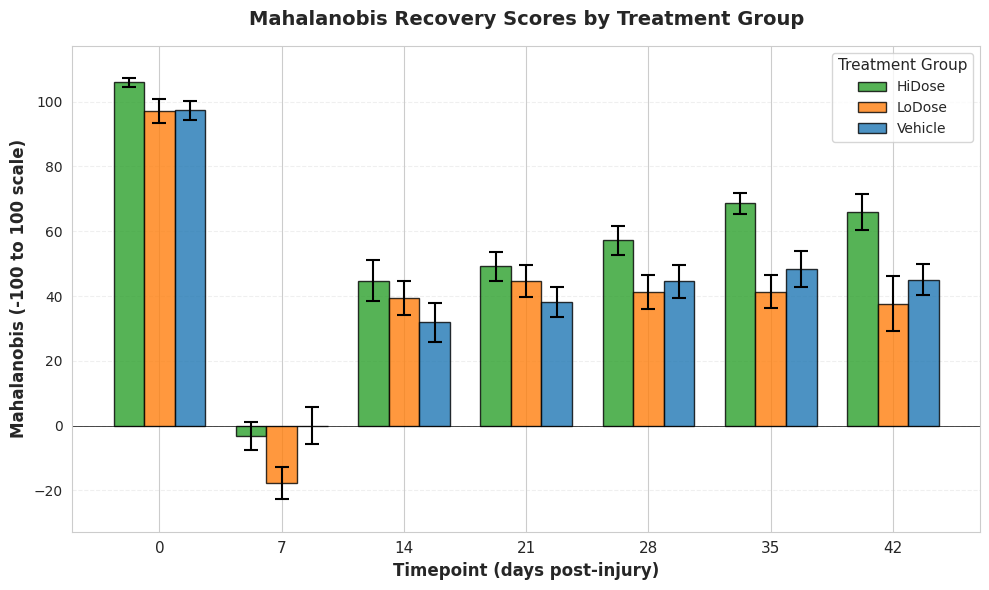

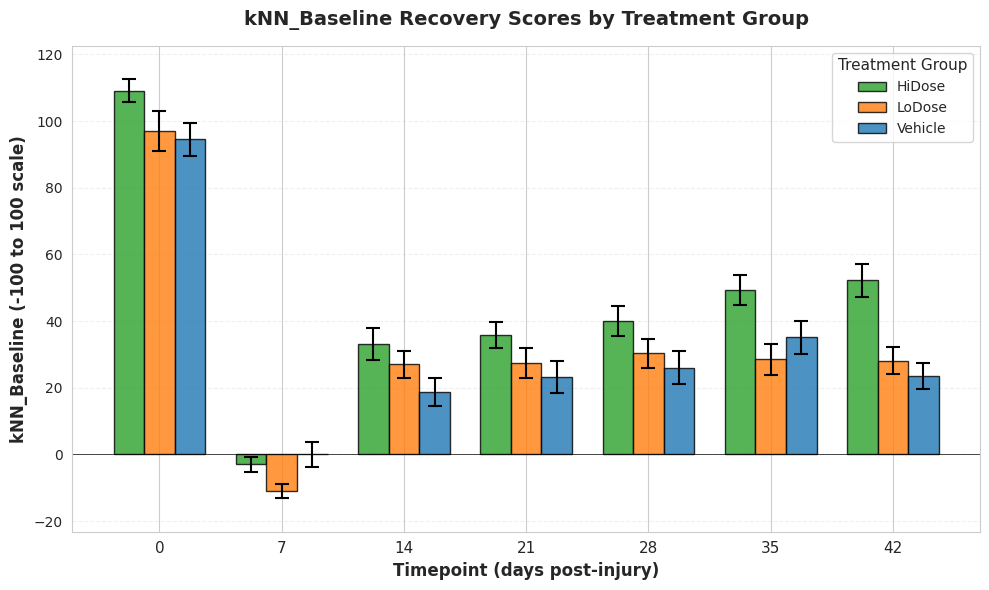

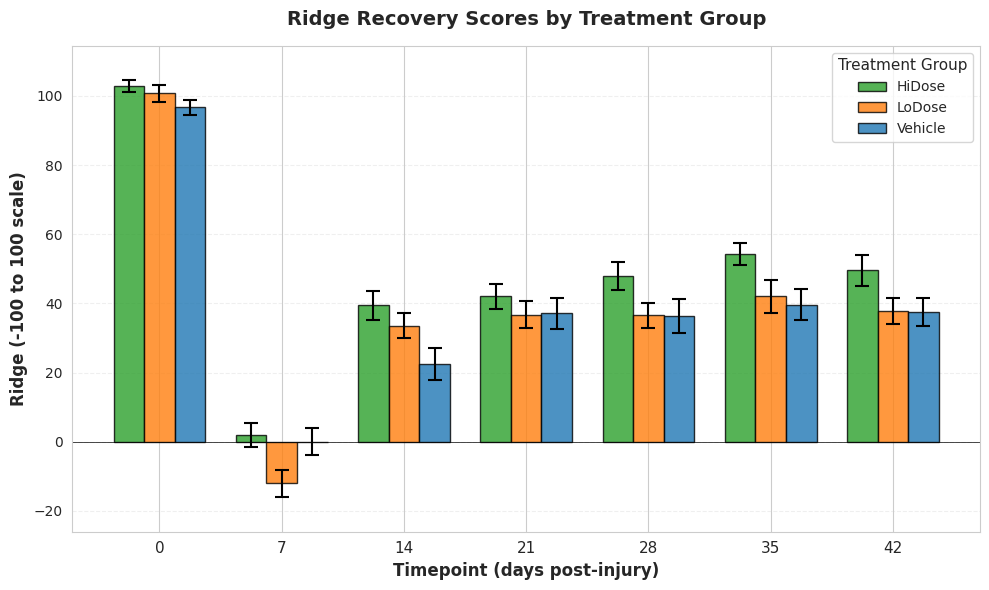

In [12]:
pf.run_visualize_scores(config, profile, df=scores_df)

## Step 5 — Visualize & Analyze Feature Importance

LOADING ALL FEATURE IMPORTANCE DATA

  Loaded CKS: 44 features
  Loaded Mahalanobis: 44 features
  Loaded Ridge: 44 features

CREATING CONSENSUS IMPORTANCE

Saved feature importance to: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/feature_imp_analysis/feature_importance.csv

Total features: 44

Limiting to top 3 per original feature...
Selected features: 18

Using top 15 for visualization:
  Original features: 9

CONSENSUS IMPORTANCE - STACKED BAR CHART

Saved: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/feature_imp_analysis/consensus_importance.png

CONSENSUS HEATMAP - BY ORIGINAL FEATURE

Saved: /content/drive/MyDrive/Colab Notebooks/Integrated_MotoRater_Pipeline_final/outputs/feature_imp_analysis/consensus_heatmap_by_original.png
  Showing 9 original features

TSFRESH FEATURE GLOSSARY
Feature                                            | Description
-----------------------------------------------------------

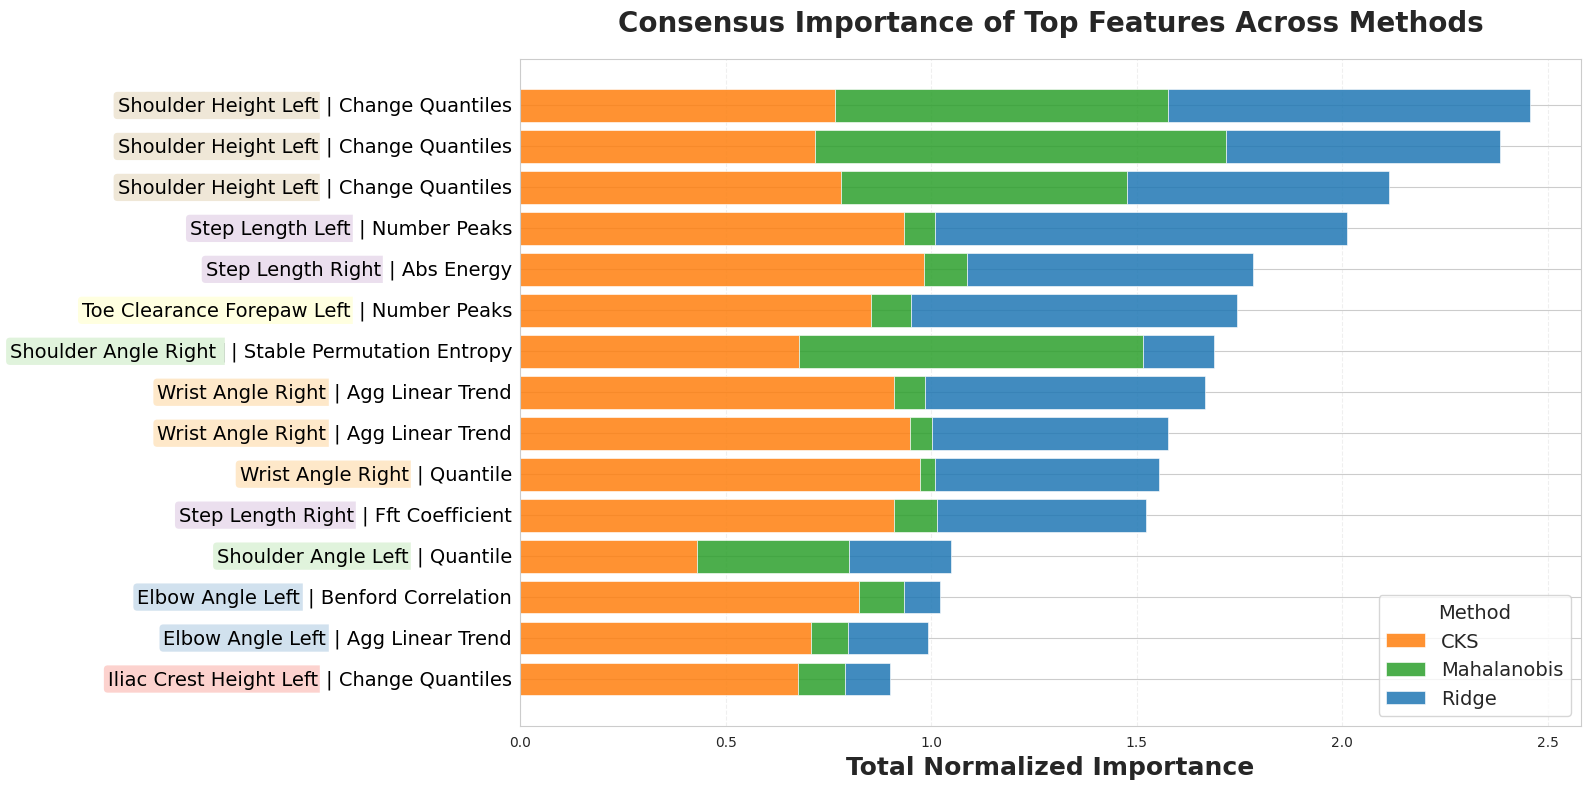

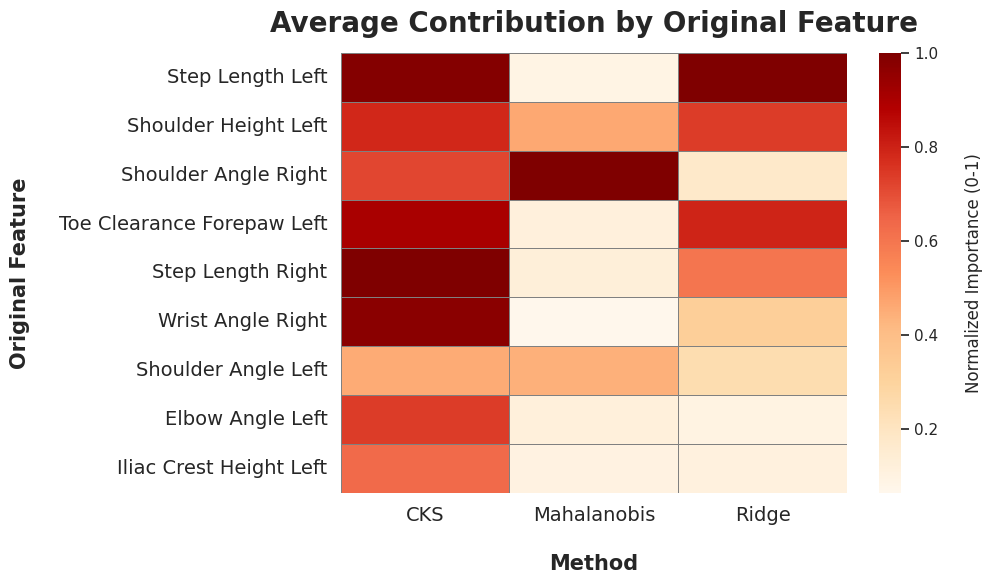

In [13]:
# Reads the per-metric importance files Stage 3 wrote to disk directly
# (whichever ones exist), rather than being passed anything in memory.
pf.run_feature_importance(config)